In [ ]:
import os
import shutil
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split

# ── 1. 경로 설정 ──────────────────────────────────────────
NORMAL_DIR  = r"C:/PyTorch Project/ResNet18/번호판 이미지 80,000장"
ECO_DIR     = r"C:/PyTorch Project/ResNet18/ECO 번호판 합본"
DATASET_DIR = r"C:/PyTorch Project/ResNet18/dataset"

# ── 2. 데이터셋 준비 ──────────────────────────────────────
def prepare_dataset():
    for split in ["train", "val", "test"]:
        for cls in ["normal", "eco"]:
            os.makedirs(f"{DATASET_DIR}/{split}/{cls}", exist_ok=True)

    def split_and_copy(src_dir, cls, n_sample=None):
        files = [f for f in os.listdir(src_dir)
                 if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        if n_sample:
            files = random.sample(files, n_sample)
        train, temp = train_test_split(files, test_size=0.2, random_state=42)
        val, test   = train_test_split(temp,  test_size=0.5, random_state=42)
        for split, file_list in [("train", train), ("val", val), ("test", test)]:
            for f in file_list:
                shutil.copy(os.path.join(src_dir, f),
                            os.path.join(DATASET_DIR, split, cls, f))

    split_and_copy(NORMAL_DIR, "normal", n_sample=500)
    split_and_copy(ECO_DIR,    "eco",    n_sample=None)
    print("데이터셋 준비 완료")

prepare_dataset()

# ── 3. 데이터 변환 ────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── 4. 데이터 로더 ────────────────────────────────────────
train_ds = datasets.ImageFolder(f"{DATASET_DIR}/train", transform=transform_train)
val_ds   = datasets.ImageFolder(f"{DATASET_DIR}/val",   transform=transform_val)
test_ds  = datasets.ImageFolder(f"{DATASET_DIR}/test",  transform=transform_val)

print(f"클래스 인덱스: {train_ds.class_to_idx}")  # {'eco':0, 'normal':1} 확인

# WeightedRandomSampler (클래스 불균형 보정)
class_counts    = [0, 0]
for _, label in train_ds:
    class_counts[label] += 1
weights         = [1.0 / class_counts[label] for _, label in train_ds]
sampler         = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(f"train: {len(train_ds)}장 | val: {len(val_ds)}장 | test: {len(test_ds)}장")

# ── 5. 모델 ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

model = models.resnet18(weights="IMAGENET1K_V1")

for param in model.parameters():   # backbone freeze
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)  # FC 교체
model = model.to(device)

# ── 6. 학습 설정 ──────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3)

# ── 7. 학습 루프 ──────────────────────────────────────────
EPOCHS          = 30
best_eco_recall = 0.0
SAVE_PATH       = r"C:/PyTorch Project/ResNet18/resnet18.pth"

for epoch in range(EPOCHS):
    # train
    model.train()
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # val
    model.eval()
    correct = total = 0
    eco_correct = eco_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds        = model(imgs).argmax(dim=1)
            correct     += (preds == labels).sum().item()
            total       += labels.size(0)
            eco_mask     = labels == 0
            eco_correct += (preds[eco_mask] == labels[eco_mask]).sum().item()
            eco_total   += eco_mask.sum().item()

    val_acc    = correct / total
    eco_recall = eco_correct / eco_total if eco_total > 0 else 0

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train_loss: {train_loss/len(train_loader):.4f} | "
          f"val_acc: {val_acc:.4f} | eco_recall: {eco_recall:.4f}")

    # val_acc → eco_recall 기준으로 변경
    if eco_recall > best_eco_recall:
        best_eco_recall = eco_recall
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  → best 저장 (eco_recall: {eco_recall:.4f})")

# ── 8. test 최종 평가 ─────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
correct = total = 0
eco_correct = eco_total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds   = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        # eco 클래스(0) 따로 확인
        eco_mask     = labels == 0
        eco_correct += (preds[eco_mask] == labels[eco_mask]).sum().item()
        eco_total   += eco_mask.sum().item()

print(f"\nTest Accuracy     : {correct/total:.4f}")
print(f"ECO Recall        : {eco_correct/eco_total:.4f}")  # 친환경 인식률

데이터셋 준비 완료
클래스 인덱스: {'eco': 0, 'normal': 1}
train: 502장 | val: 63장 | test: 63장
device: cuda
Epoch 01/30 | train_loss: 0.7454 | val_acc: 0.8413 | eco_recall: 0.4615
  → best 저장 (eco_recall: 0.4615)
Epoch 02/30 | train_loss: 0.5128 | val_acc: 0.8730 | eco_recall: 0.6154
  → best 저장 (eco_recall: 0.6154)
Epoch 03/30 | train_loss: 0.3952 | val_acc: 0.7778 | eco_recall: 0.7692
  → best 저장 (eco_recall: 0.7692)
Epoch 04/30 | train_loss: 0.3648 | val_acc: 0.7937 | eco_recall: 0.8462
  → best 저장 (eco_recall: 0.8462)
Epoch 05/30 | train_loss: 0.3442 | val_acc: 0.7937 | eco_recall: 0.8462
Epoch 06/30 | train_loss: 0.2886 | val_acc: 0.8413 | eco_recall: 0.8462
Epoch 07/30 | train_loss: 0.2785 | val_acc: 0.8730 | eco_recall: 0.8462
Epoch 08/30 | train_loss: 0.2519 | val_acc: 0.8095 | eco_recall: 0.9231
  → best 저장 (eco_recall: 0.9231)
Epoch 09/30 | train_loss: 0.2421 | val_acc: 0.9048 | eco_recall: 0.6923
Epoch 10/30 | train_loss: 0.1937 | val_acc: 0.8571 | eco_recall: 0.8462
Epoch 11/30 | train_los

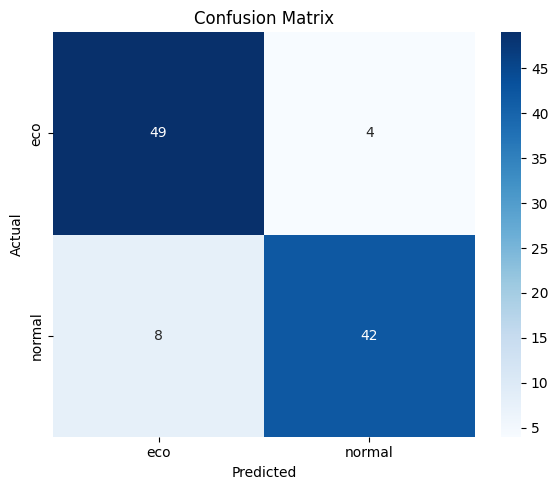


── Classification Report ──────────────────────
              precision    recall  f1-score   support

         eco     0.8596    0.9245    0.8909        53
      normal     0.9130    0.8400    0.8750        50

    accuracy                         0.8835       103
   macro avg     0.8863    0.8823    0.8830       103
weighted avg     0.8856    0.8835    0.8832       103



In [12]:
# ── 9. Confusion Matrix 및 상세 지표 ─────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ["eco", "normal"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(r"C:/PyTorch Project/ResNet18/confusion_matrix.png")
plt.show()

# 상세 지표
print("\n── Classification Report ──────────────────────")
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4))